# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 04 — La malla real × sintético

**Esta es la pregunta del taller.** Los notebooks anteriores construyeron las piezas: el
dataset con splits purgados (01), la arquitectura downstream congelada y los baselines
clásicos (02), y seis generadores auditados contra los hechos estilizados (03). Aquí se
responde: **¿cuántos datos sintéticos ayudan, en qué régimen de escasez de datos reales, y
qué generador los produce mejor?**

### El experimento

Para cada combinación (N_real, generador, ratio, semilla):

1. Se submuestrean `N_real` ventanas del train.
2. El generador se **reentrena con esas `N_real` ventanas y solo esas**.
3. Se generan `N_synth = ratio × N_real` ventanas sintéticas.
4. Se entrena la arquitectura **congelada** del notebook 02 sobre la mezcla.
5. Se evalúa en el **test real**, intocado y siempre el mismo.

### Las cuatro reglas que hacen esto interpretable

| Regla | Por qué |
|---|---|
| **El generador se reentrena en cada celda** | Ajustarlo con las 102k ventanas y luego *simular* escasez sería fuga: los sintéticos llevarían información de datos que el escenario declara no tener, y la curva saldría optimista. |
| **Submuestreo por fechas, no por filas** | En una fecha dada todas las ventanas del panel cuentan la misma historia de mercado. Un muestreo de filas daría un N nominal muy superior al efectivo. |
| **Validación siempre real** | Si el early-stopping mirase datos sintéticos, optimizaríamos la distribución equivocada. |
| **Arquitectura e hiperparámetros congelados** | Si una celda rinde distinto, la única explicación posible son los datos. |

> **Métrica principal: `delta_r2`** — la ganancia de R² en test de cada celda frente a la
> celda de *solo real* con el mismo N. Responde literalmente al enunciado: para el mismo
> presupuesto de datos reales, ¿cuánto añade el sintético? El umbral de relevancia lo fijó
> el notebook 02: **±0,006**, la dispersión entre semillas del modelo con datos reales.
> Cualquier efecto por debajo de eso es ruido de optimización, no señal.

## 0 · Setup y configuración de la malla

**Tres tamaños de malla.** `REDUCIDA` valida el pipeline y cubre el régimen de escasez;
`COMPLETA` añade el extremo de datos abundantes; `RATIOS_FINOS` mantiene los mismos tres
niveles de escasez y **refina el eje del presupuesto sintético por debajo de 1×**.

El presupuesto sintético se declara siempre como **multiplicador** de los reales de la
celda (`n_synth = ratio × n_real`), nunca como un conteo absoluto: así una fila con
`ratio=3` significa lo mismo con N=250 que con N=3.000, que es lo que permite comparar
regímenes de escasez entre sí. (La lectura complementaria —presupuesto sintético fijo
mientras varían los reales— es la §2.5, y necesita el otro diseño precisamente porque
un multiplicador no puede mantenerse constante a lo largo de ese eje.)

**Por qué 0,25× · 0,5× · 0,75× y no solo múltiplos enteros.** Con la malla `[0, 1, 3]` el
primer punto medido ya duplica el conjunto de entrenamiento: entre "nada de sintético" y
"tanto sintético como real" no hay ninguna observación. Si el efecto del dato sintético
cambia de signo ahí —y es donde más razones hay para esperarlo, porque es donde la mezcla
pasa de estar dominada por el dato real a no estarlo— la malla anterior no puede verlo.
Los tres ratios fraccionarios miden precisamente ese tramo: 0,25× añade una ventana
sintética por cada cuatro reales, una dosis que un generador mediocre todavía no puede
arruinar.

Los ratios 10×, 20× y 30× quedan **fuera a propósito**: multiplicaban el coste por cuatro
(153 min frente a 37) y su única función era buscar el punto de giro por arriba, que es
una pregunta distinta y se puede añadir después sin rehacer nada — la malla es reanudable
y la clave de reanudación incluye el ratio.

**Submuestreo de la validación.** La validación real tiene 17.146 ventanas y se evalúa en
cada época de cada celda: a N pequeño ese coste fijo **domina el tiempo total** de la malla
(medido: ~45 s por celda con N=300). Como su único papel es elegir la época de la que se
conservan los pesos, 5.000 ventanas reales bastan de sobra y el coste por celda cae unas
tres veces. Es una decisión de eficiencia que no toca ninguna comparación: la validación es
idéntica en todas las celdas.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.malla import (plan_de_malla, ejecutar_malla, resumir, delta_vs_solo_real,
                       delta_pareado, umbral_ruido_por_n, SOLO_REAL)
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
print("Device:", device)

# ---- Tamaño de la malla -------------------------------------------------
MALLA = "RATIOS_FINOS"      # "REDUCIDA", "RATIOS_FINOS" o "COMPLETA"

CONFIG_MALLA = {
    "REDUCIDA": dict(n_reales=[250, 1000, 3000], ratios=[0, 1, 3], seeds=[0, 1, 2]),
    # Mismos niveles de escasez, eje de ratio con resolución fina por debajo de 1x:
    # es el tramo que la malla REDUCIDA se saltaba entero.
    "RATIOS_FINOS": dict(n_reales=[250, 1000, 3000],
                         ratios=[0, 0.25, 0.5, 0.75, 1, 3, 5], seeds=[0, 1, 2]),
    "COMPLETA": dict(n_reales=[250, 1000, 3000, 10000], ratios=[0, 1, 3, 10], seeds=[0, 1, 2]),
}[MALLA]

GENERADORES = ["jitter", "gaussiana", "block_bootstrap", "vae", "wgan_gp", "realnvp"]
N_VAL = 5000                # submuestra de validación (real) — ver nota arriba
RUTA_CSV = cfg.out_dir / f"malla_{MALLA.lower()}.csv"

print(f"Malla {MALLA}: {CONFIG_MALLA}")
print(f"Resultados -> {RUTA_CSV}")

Device: cuda
Malla RATIOS_FINOS: {'n_reales': [250, 1000, 3000], 'ratios': [0, 0.25, 0.5, 0.75, 1, 3, 5], 'seeds': [0, 1, 2]}
Resultados -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\data\processed\malla_ratios_finos.csv


In [2]:
# ---- Datos: todo lo que la malla puede tocar ----------------------------
d   = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
ref = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
meta = pd.read_parquet(cfg.out_dir / "windows_meta.parquet")
meta_train = meta[meta.split == "train"].reset_index(drop=True)

S = lambda a, m, s: ((a - std[m]) / std[s]).astype(np.float32)

# validación real submuestreada, fija para TODAS las celdas
rng_val = np.random.default_rng(cfg.seed)
iv = rng_val.choice(len(d["X_val"]), min(N_VAL, len(d["X_val"])), replace=False)

CONTEXTO = dict(
    Xs_train=S(d["X_train"], "x_mu", "x_sd"), ys_train=S(d["y_train"], "y_mu", "y_sd"),
    meta_train=meta_train,
    Xs_val=S(d["X_val"], "x_mu", "x_sd")[iv], ys_val=S(d["y_val"], "y_mu", "y_sd")[iv],
    Xs_test=S(d["X_test"], "x_mu", "x_sd"), y_test_fisico=d["y_test"],
    std=std, ref=ref, device=device,
)

print(f"Arquitectura congelada: {ref['arch']} {ref['arch_kwargs']}")
print(f"Referencia con datos reales completos: R² test = "
      f"{np.mean([v['test_r2'] for v in ref['metricas_seeds'].values()]):.4f}")
print(f"train {meta_train.shape[0]:,} ventanas / {meta_train.date_t.nunique():,} fechas | "
      f"val {len(iv):,} (submuestra) | test {len(d['X_test']):,}")

Arquitectura congelada: gru {'hidden': 72, 'layers': 3, 'fc': 72}
Referencia con datos reales completos: R² test = 0.4716
train 102,406 ventanas / 2,372 fechas | val 5,000 (submuestra) | test 24,613


## 1 · Ejecución de la malla

El plan se ordena de **coste creciente**: si la ejecución se interrumpe, lo ya calculado es
el régimen de escasez, que es el que más importa. Cada celda se escribe al CSV en cuanto
termina, así que **relanzar esta celda reanuda donde se quedó** sin recalcular nada.

In [3]:
plan = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
print(f"{len(plan)} celdas en el plan "
      f"({len(CONFIG_MALLA['n_reales'])} niveles de N × "
      f"{len(CONFIG_MALLA['ratios'])} ratios × {len(GENERADORES)} generadores × "
      f"{len(CONFIG_MALLA['seeds'])} semillas)")

333 celdas en el plan (3 niveles de N × 7 ratios × 6 generadores × 3 semillas)


In [4]:
t0 = time.time()
df = ejecutar_malla(plan, RUTA_CSV, **CONTEXTO)
print(f"\nMalla terminada en {(time.time() - t0)/60:.1f} min | {len(df)} celdas en el CSV")

Malla: 333 celdas | ya hechas: 333 | pendientes: 0

Malla terminada en 0.0 min | 333 celdas en el CSV


## 2 · Resultados

### 2.1 Tabla resumen

In [5]:
resumen = resumir(df)
delta = delta_vs_solo_real(resumen)

# referencia de cada N: cuánto rinde el modelo con SOLO datos reales
print("Referencia — solo datos reales:")
display(resumen[resumen.generador == SOLO_REAL][["n_real", "test_r2_media", "test_r2_sd"]].round(4))

# tabla principal: ganancia frente a esa referencia
tabla = delta.pivot_table(index=["n_real", "generador"], columns="ratio", values="delta_r2")
tabla.round(4)

Referencia — solo datos reales:


,n_real,test_r2_media,test_r2_sd
18,250,0.1514,0.1149
55,1000,0.1994,0.1614
92,3000,0.3380,0.0223


ratio                    0.248   0.250   0.500   0.750   0.752   1.000  \
n_real generador                                                         
250    block_bootstrap -0.0278     NaN -0.0367     NaN -0.0403 -0.0435   
       gaussiana       -0.0131     NaN -0.0187     NaN -0.0512 -0.0609   
       jitter          -0.0062     NaN  0.0096     NaN  0.0066  0.0006   
       realnvp         -0.0267     NaN -0.0228     NaN -0.0280 -0.0198   
       vae             -0.0085     NaN  0.0053     NaN -0.0290 -0.0328   
       wgan_gp         -0.2534     NaN -0.2830     NaN -0.2900 -0.2984   
1000   block_bootstrap     NaN  0.1024  0.0934  0.0644     NaN  0.0611   
       gaussiana           NaN  0.0616  0.0639  0.0517     NaN  0.0344   
       jitter              NaN  0.0986  0.1149  0.1156     NaN  0.1174   
       realnvp             NaN  0.1069  0.1059  0.1059     NaN  0.1043   
       vae                 NaN  0.0953  0.0915  0.0636     NaN  0.0641   
       wgan_gp             NaN  0.0233 -0.0126 -0.0675     NaN -0.0724   
3000   block_bootstrap     NaN  0.0143  0.0275  0.0343     NaN  0.0173   
       gaussiana           NaN -0.0388 -0.0687 -0.0849     NaN -0.1012   
       jitter              NaN  0.0199  0.0317  0.0312     NaN  0.0323   
       realnvp             NaN  0.0186  0.0379  0.0330     NaN  0.0515   
       vae                 NaN -0.0153 -0.0238 -0.0232     NaN -0.0298   
       wgan_gp             NaN -0.0337 -0.0839 -0.1092     NaN -0.1285   

ratio                    3.000   5.000  
n_real generador                        
250    block_bootstrap -0.0507  0.0191  
       gaussiana       -0.1081 -0.0109  
       jitter          -0.0271  0.0764  
       realnvp         -0.0689  0.0209  
       vae             -0.1519  0.0187  
       wgan_gp         -0.2874 -0.2911  
1000   block_bootstrap  0.0967  0.1025  
       gaussiana        0.0026 -0.0454  
       jitter           0.1648  0.1746  
       realnvp          0.1468  0.1307  
       vae              0.0655  0.0628  
       wgan_gp          0.0404  0.0987  
3000   block_bootstrap  0.0190  0.0189  
       gaussiana       -0.1524 -0.1803  
       jitter           0.0523  0.0495  
       realnvp          0.0773  0.0814  
       vae             -0.0422 -0.0658  
       wgan_gp         -0.1327 -0.1703

### 2.1.b Análisis pareado: la comparación que sí es válida

**Corrección metodológica importante.** El notebook 02 fijó un umbral de relevancia de
±0,006 midiendo la dispersión entre semillas del modelo entrenado con las **102.406
ventanas reales completas**. Ese umbral **no vale aquí**: en régimen de escasez la
dispersión entre semillas es de 5 a 11 veces mayor, porque cada semilla sortea un
submuestreo distinto de datos reales y eso mueve el R² mucho más que cualquier efecto del
sintético.

La solución no es subir el umbral, sino **parear**. La semilla determina qué ventanas
reales "existen" en el escenario, así que comparamos cada celda contra la celda de
solo-real **de su misma semilla**: la varianza del submuestreo se cancela y queda solo el
efecto del dato sintético. Con 3 semillas exigimos |t| ≥ 2,5 para hablar de efecto; por
debajo, la celda se declara **no concluyente** en lugar de inventar una conclusión.

In [6]:
print("Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):")
u = umbral_ruido_por_n(df)
display(pd.DataFrame({"sd_entre_semillas": u.round(4),
                      "veces el umbral del nb02 (0,006)": (u / 0.006).round(0)}))

par = delta_pareado(df)
print("\nΔ R² pareado por semilla — solo las celdas con veredicto:")
concluyentes = par[par.veredicto != "no concluyente"].sort_values("t")
display(concluyentes[["n_real", "generador", "ratio", "delta_medio", "ee", "t", "veredicto"]].round(4))
print(f"\n{len(par)} celdas: {(par.veredicto=='mejora').sum()} mejoran, "
      f"{(par.veredicto=='empeora').sum()} empeoran, "
      f"{(par.veredicto=='no concluyente').sum()} no concluyentes")

Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):


,sd_entre_semillas,"veces el umbral del nb02 (0,006)"
n_real,,
250,0.1149,19.0
1000,0.1614,27.0
3000,0.0223,4.0



Δ R² pareado por semilla — solo las celdas con veredicto:


,n_real,generador,ratio,delta_medio,ee,t,veredicto
83,3000,gaussiana,5.000,-0.1803,0.0153,-11.7609,empeora
82,3000,gaussiana,3.000,-0.1524,0.0290,-5.2514,empeora
97,3000,vae,0.500,-0.0238,0.0070,-3.4189,empeora
101,3000,vae,5.000,-0.0658,0.0198,-3.3270,empeora
8,250,gaussiana,0.752,-0.0512,0.0185,-2.7726,empeora
107,3000,wgan_gp,5.000,-0.1703,0.0621,-2.7430,empeora
26,250,vae,0.752,-0.0290,0.0109,-2.6541,empeora
1,250,block_bootstrap,0.500,-0.0367,0.0146,-2.5232,empeora
88,3000,jitter,3.000,0.0523,0.0201,2.6049,mejora
17,250,jitter,5.000,0.0764,0.0287,2.6591,mejora



108 celdas: 14 mejoran, 8 empeoran, 86 no concluyentes


### 2.2 La figura del taller: ganancia frente a proporción de sintéticos

Un panel por nivel de escasez. La banda gris es el **umbral de relevancia** (±0,006, la
dispersión entre semillas del notebook 02): cualquier curva dentro de esa banda es ruido,
no efecto.

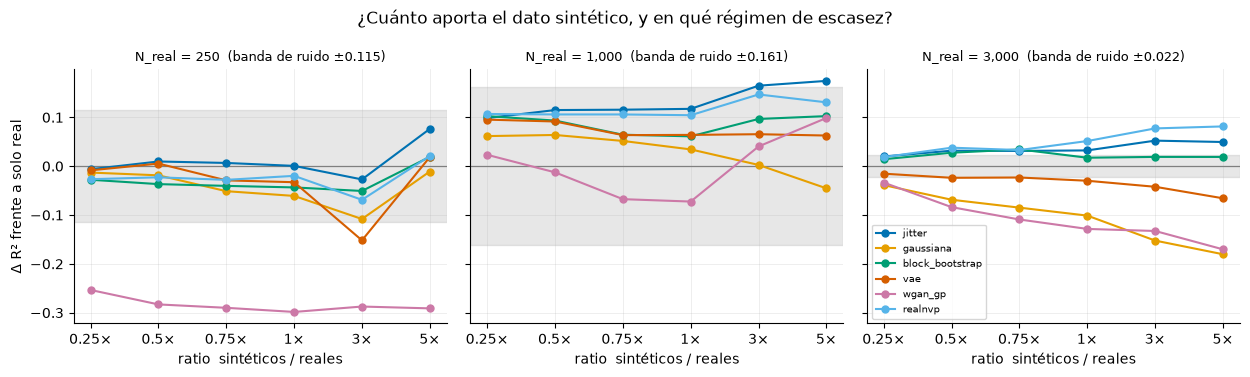

In [7]:
n_paneles = len(CONFIG_MALLA["n_reales"])
fig, axes = plt.subplots(1, n_paneles, figsize=(4.2 * n_paneles, 3.8), sharey=True)
axes = np.atleast_1d(axes)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
# La banda es la dispersión entre semillas del solo-real EN CADA N (ver §2.1.b),
# no el ±0,006 del notebook 02, que solo vale con las 102k ventanas completas.
UMBRAL_POR_N = umbral_ruido_por_n(df)
#: Los ratios con sintético, en el orden del eje (el 0 es la referencia solo-real,
#: que se dibuja como banda y línea, no como punto de las series).
RATIOS_EJE = [r for r in sorted(CONFIG_MALLA["ratios"]) if r > 0]


def pos_ratio(r: float) -> int:
    """Posición en el eje del nominal más cercano al ratio REALIZADO.

    El CSV guarda el ratio que de verdad se ejecutó, no el que se pidió:
    `ejecutar_celda` lo recalcula como n_synth / n_real, y n_synth es un
    entero redondeado. Con N=250 y ratio 0,25 salen round(62,5) = 62 ventanas,
    es decir 0,248; con 0,75 salen 188, es decir 0,752. Buscar el nominal por
    igualdad de floats falla ahí. Se asigna al más próximo, que es inequívoco
    porque los niveles distan mucho más entre sí que el error de redondeo.
    """
    return int(np.argmin([abs(r - x) for x in RATIOS_EJE]))

for ax, n in zip(axes, CONFIG_MALLA["n_reales"]):
    sub = delta[delta.n_real == n]
    u = UMBRAL_POR_N[n]
    ax.axhspan(-u, u, color=PALETTE["grey"], alpha=0.18, zorder=0)
    ax.axhline(0, color=PALETTE["grey"], lw=0.9)
    for col, g in zip(colores, GENERADORES):
        s = sub[sub.generador == g].sort_values("ratio")
        if len(s):
            # Posiciones equiespaciadas, no el valor del ratio: en eje lineal los
            # ratios bajos (1, 3, 5) se aplastarían contra el margen izquierdo, y es
            # justo ahí donde se decide si la curva gira. Un eje log tampoco vale:
            # el 0 del solo-real no cabe en él.
            xp = [pos_ratio(r) for r in s.ratio]
            ax.plot(xp, s.delta_r2, "o-", color=col, lw=1.5, ms=5, label=g)
    ax.set_xticks(range(len(RATIOS_EJE)))
    ax.set_xticklabels([f"{r:g}×" for r in RATIOS_EJE])
    ax.set_title(f"N_real = {n:,}  (banda de ruido ±{u:.3f})", fontsize=9)
    ax.set_xlabel("ratio  sintéticos / reales")
    _style(ax)
axes[0].set_ylabel("Δ R² frente a solo real")
axes[-1].legend(fontsize=7, loc="best")
fig.suptitle("¿Cuánto aporta el dato sintético, y en qué régimen de escasez?")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "14_delta_r2_por_escasez.png", dpi=120, bbox_inches="tight")

### 2.3 Curvas de aprendizaje: R² frente a datos reales disponibles

La lectura complementaria — y la que reproduce la forma de la gráfica que el profesor
mostró en clase. La línea negra discontinua es el techo: el modelo entrenado con las
**102.406 ventanas reales completas** (notebook 02).

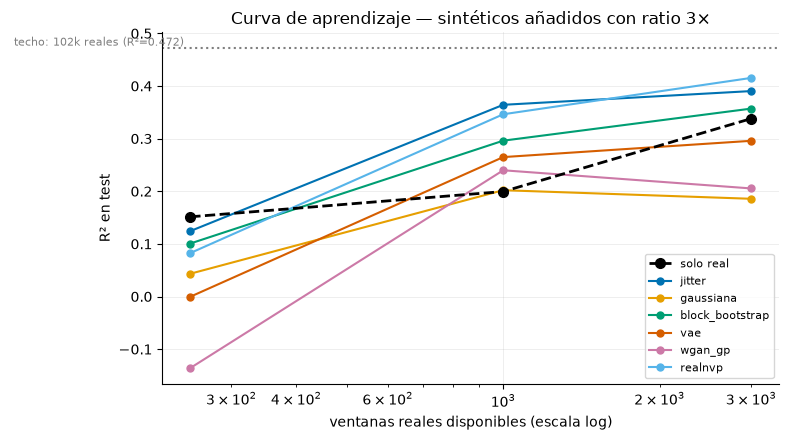

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
techo = np.mean([v["test_r2"] for v in ref["metricas_seeds"].values()])

base = resumen[resumen.generador == SOLO_REAL].sort_values("n_real")
ax.plot(base.n_real, base.test_r2_media, "o--", color="black", lw=2, ms=7,
        label="solo real", zorder=5)

RATIO_FOCO = 3 if 3 in CONFIG_MALLA["ratios"] else max(CONFIG_MALLA["ratios"])
for col, g in zip(colores, GENERADORES):
    s = resumen[(resumen.generador == g) & (resumen.ratio == RATIO_FOCO)].sort_values("n_real")
    if len(s):
        ax.plot(s.n_real, s.test_r2_media, "o-", color=col, lw=1.5, ms=5, label=g)

ax.axhline(techo, color=PALETTE["grey"], ls=":", lw=1.5)
ax.text(ax.get_xlim()[0], techo, f" techo: 102k reales (R²={techo:.3f})",
        va="bottom", fontsize=8, color=PALETTE["grey"])
ax.set_xscale("log")
ax.set_xlabel("ventanas reales disponibles (escala log)")
ax.set_ylabel("R² en test")
ax.set_title(f"Curva de aprendizaje — sintéticos añadidos con ratio {RATIO_FOCO}×")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "15_curva_aprendizaje.png", dpi=120, bbox_inches="tight")

### 2.4 ¿Predice la auditoría del notebook 03 el efecto downstream?

La pregunta que cierra el círculo del taller. En el notebook 03 medimos cada generador **sin
mirar el modelo downstream**, en dos ejes: **fidelidad** (discriminative AUC, curtosis,
clustering, distancias marginales y de dependencia) y **utilidad** (el ratio TSTR/TRTR, que
entrena un modelo *solo* con datos sintéticos). Si esas métricas anticipan la ganancia real
de la malla, se puede elegir generador midiendo el sintético, sin barrer una malla entera.

> **Los números se leen del CSV que el notebook 03 persiste**, no de una tabla copiada a
> mano. Es una precaución con historia: la malla **reentrena** cada generador en cada celda,
> así que si los hiperparámetros del 03 y los de `malla.construir_generador` se desviaran, una
> tabla escrita a mano seguiría mostrando las cifras viejas y la correlación de esta sección
> compararía dos cosas distintas sin avisar.

Se cruza contra el **delta pareado** (§2.1.b) y se calcula la correlación de rangos de
Spearman por nivel de escasez, porque el resultado depende críticamente del régimen. Ojo con
los **signos**: en `discriminative_auc`, las distancias (`w1_*`, `err_*`) menos es mejor, así
que una correlación **negativa** significa que la métrica predice bien; en `curtosis_x`,
`acf_abs_lag1` y `ratio_tstr_trtr` es al revés.

In [9]:
# Auditoría del notebook 03, leída del CSV que ese notebook persiste en su §6.
RUTA_AUD, RUTA_TSTR = cfg.out_dir / "auditoria_nb03.csv", cfg.out_dir / "tstr_nb03_resumen.csv"
if not RUTA_AUD.exists():
    raise FileNotFoundError(f"Falta {RUTA_AUD.name}: ejecuta antes el notebook 03, "
                            "que lo genera en su sección de persistencia.")

AUDITORIA_NB03 = pd.read_csv(RUTA_AUD, index_col=0).rename_axis("generador").reset_index()
if RUTA_TSTR.exists():   # la utilidad TSTR es también una métrica del 03
    AUDITORIA_NB03 = AUDITORIA_NB03.merge(
        pd.read_csv(RUTA_TSTR).rename(columns={"brazo": "generador"})[
            ["generador", "ratio_tstr_trtr"]], on="generador", how="left")

# Ordenadas por eje: fidelidad global, forma, dependencia y utilidad.
METRICAS = ["discriminative_auc", "w1_x_col_media", "curtosis_x", "acf_abs_lag1",
            "err_corr_xx_spearman", "err_corr_xx_pearson", "err_corr_xy", "ratio_tstr_trtr"]
METRICAS = [m for m in METRICAS if m in AUDITORIA_NB03]
print(f"Auditoría del nb03: {len(AUDITORIA_NB03)} generadores × {len(METRICAS)} métricas")

filas = []
for n in list(CONFIG_MALLA["n_reales"]) + ["todos"]:
    sub = par if n == "todos" else par[par.n_real == n]
    gan = sub.groupby("generador")["delta_medio"].mean().rename("ganancia").reset_index()
    c = AUDITORIA_NB03.merge(gan, on="generador")
    filas.append(pd.Series(c[METRICAS].corrwith(c["ganancia"], method="spearman"), name=n))
corr = pd.DataFrame(filas)
corr.index.name = "N_real"

print("\nCorrelación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:")
display(corr.round(2))

# El mejor predictor, en valor absoluto y sobre todos los regímenes a la vez
mejor = corr.loc["todos"].abs().idxmax()
print(f"Mejor predictor sobre el conjunto de la malla: {mejor} "
      f"(Spearman {corr.loc['todos', mejor]:+.2f})")

n_ref = CONFIG_MALLA["n_reales"][1] if len(CONFIG_MALLA["n_reales"]) > 1 else CONFIG_MALLA["n_reales"][0]
orden = (par[par.n_real == n_ref].groupby("generador")["delta_medio"].mean()
         .sort_values(ascending=False))
print(f"\nOrden de mérito downstream con N_real = {n_ref}:")
print("  " + "  >  ".join(orden.index))
print("Orden por curtosis en el nb03 (colas más realistas primero):")
print("  " + "  >  ".join(AUDITORIA_NB03.sort_values("curtosis_x", ascending=False).generador))
if "ratio_tstr_trtr" in AUDITORIA_NB03:
    print("Orden por utilidad TSTR en el nb03 (más información conservada primero):")
    print("  " + "  >  ".join(
        AUDITORIA_NB03.sort_values("ratio_tstr_trtr", ascending=False).generador))
print("\n(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)")

Auditoría del nb03: 6 generadores × 8 métricas

Correlación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:


,discriminative_auc,w1_x_col_media,curtosis_x,acf_abs_lag1,err_corr_xx_spearman,err_corr_xx_pearson,err_corr_xy,ratio_tstr_trtr
N_real,,,,,,,,
250,-0.83,-0.83,0.66,0.77,-0.89,0.14,0.14,0.83
1000,-0.83,-0.83,0.66,0.77,-0.89,0.14,0.14,0.83
3000,-0.77,-0.77,0.60,0.71,-0.83,0.26,0.26,0.89
todos,-0.83,-0.83,0.66,0.77,-0.89,0.14,0.14,0.83


Mejor predictor sobre el conjunto de la malla: err_corr_xx_spearman (Spearman -0.89)

Orden de mérito downstream con N_real = 1000:
  jitter  >  realnvp  >  block_bootstrap  >  vae  >  gaussiana  >  wgan_gp
Orden por curtosis en el nb03 (colas más realistas primero):
  block_bootstrap  >  jitter  >  realnvp  >  wgan_gp  >  vae  >  gaussiana
Orden por utilidad TSTR en el nb03 (más información conservada primero):
  realnvp  >  jitter  >  vae  >  block_bootstrap  >  wgan_gp  >  gaussiana

(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)


### 2.5 Error frente al número de reales, con presupuesto sintético **absoluto**

Las dos figuras anteriores fijan el sintético en **proporción** al real: la §2.2 barre el
ratio, y la §2.3 lo congela en 3×. Esta sección hace la pregunta desde el otro lado, que es
la lectura que se mostró en clase:

> Fijado un **presupuesto absoluto** de sintéticos —500, 1.000, 20.000 ventanas, las que
> sean—, ¿cómo cae el error a medida que conseguimos más datos reales?

No es una reordenación de los datos de arriba: es una malla distinta. Con el diseño de ratio
fijo, `n_synth = ratio × n_real` **cambia en cada punto de la curva**, así que una serie de
n_synth constante tendría un solo punto. Por eso `src/malla.py` admite ahora declarar el
presupuesto de las dos formas (`resolver_presupuesto`) y `plan_de_curvas` construye el plan
con el conteo fijo.

**Lo que esta malla añade que la anterior no podía dar:**

| | malla de ratios (§2.1–2.4) | malla de curvas (esta) |
|---|---|---|
| Reales | 250 · 1.000 · 3.000 | 250 · 1.000 · 3.000 · 10.000 · **20.000** |
| Sintéticos | ratio 1× y 3× | 0 · 500 · 1.000 · 3.000 · 7.000 · **20.000** |
| Ratio máximo alcanzado | 3× | **80×** (250 reales + 20.000 sintéticos) |

Ese ratio de 80× es lo que permite contrastar por fin la **H2** del §3, que hasta ahora se
quedaba sin evidencia porque el rango probado se agotaba en 3×.

**Métrica.** El eje y es `val_mse`: el error en la validación **real**, que es el criterio
con el que se eligen los pesos de cada celda. Está en escala estandarizada (no en unidades
de ln σ, como el `test_mse`) y se mide sobre la submuestra fija de 5.000 ventanas descrita
en el §0 — idéntica en las dos mallas, así que las celdas son comparables entre sí. Ambos
ejes van en escala logarítmica.


In [10]:
from src.malla import (plan_de_curvas, plot_curvas_error_por_generador,
                       plot_curvas_error_todos)

# Presupuestos ABSOLUTOS: cada uno es una curva de la figura, constante a lo
# largo de todo el eje x. El nivel 0 es la referencia de solo real.
N_REALES_CURVAS = [250, 1000, 3000, 10000, 20000]
N_SINTETICOS    = [0, 500, 1000, 3000, 7000, 20000]
RUTA_CURVAS     = cfg.out_dir / "malla_curvas.csv"

plan_curvas = plan_de_curvas(n_reales=N_REALES_CURVAS, generadores=GENERADORES,
                             n_sinteticos=N_SINTETICOS, seeds=CONFIG_MALLA["seeds"])

n_ref = len(N_REALES_CURVAS) * len(CONFIG_MALLA["seeds"])
print(f"{len(plan_curvas)} celdas: {n_ref} de referencia (solo real) + "
      f"{len(plan_curvas) - n_ref} con sintéticos")
print(f"  {len(N_REALES_CURVAS)} niveles de reales x "
      f"{len(N_SINTETICOS) - 1} presupuestos sintéticos x "
      f"{len(GENERADORES)} generadores x {len(CONFIG_MALLA['seeds'])} semillas")
print(f"  n_train máximo: {max(N_REALES_CURVAS) + max(N_SINTETICOS):,} ventanas")
print(f"Resultados -> {RUTA_CURVAS}")


465 celdas: 15 de referencia (solo real) + 450 con sintéticos
  5 niveles de reales x 5 presupuestos sintéticos x 6 generadores x 3 semillas
  n_train máximo: 40,000 ventanas
Resultados -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\data\processed\malla_curvas.csv


In [11]:
# Mismo CONTEXTO que la malla de ratios: mismos datos, misma validación
# submuestreada, misma arquitectura congelada. Sin eso las dos mallas no serían
# comparables. Reanudable igual que la otra: relanzar no recalcula nada.
t0 = time.time()
df_curvas = ejecutar_malla(plan_curvas, RUTA_CURVAS, **CONTEXTO)
print(f"\nMalla de curvas terminada en {(time.time() - t0)/60:.1f} min | "
      f"{len(df_curvas)} celdas en el CSV")


Malla: 465 celdas | ya hechas: 372 | pendientes: 93


[  1/93] N= 20000 ninguno          synth=     0 s=0 -> R² 0.4185 (37s) | ETA 57 min


[  2/93] N= 20000 ninguno          synth=     0 s=1 -> R² 0.4623 (35s) | ETA 55 min


[  3/93] N= 20000 ninguno          synth=     0 s=2 -> R² 0.4162 (35s) | ETA 54 min


[  4/93] N= 20000 jitter           synth=   500 s=0 -> R² 0.4060 (36s) | ETA 53 min


...

[ 89/93] N= 20000 wgan_gp          synth= 20000 s=1 -> R² 0.3910 (88s) | ETA 3 min


[ 90/93] N= 20000 wgan_gp          synth= 20000 s=2 -> R² 0.2703 (89s) | ETA 2 min


[ 91/93] N= 20000 realnvp          synth= 20000 s=0 -> R² 0.4195 (78s) | ETA 2 min


[ 92/93] N= 20000 realnvp          synth= 20000 s=1 -> R² 0.4500 (79s) | ETA 1 min


[ 93/93] N= 20000 realnvp          synth= 20000 s=2 -> R² 0.4363 (79s) | ETA 0 min

Malla de curvas terminada en 78.8 min | 465 celdas en el CSV


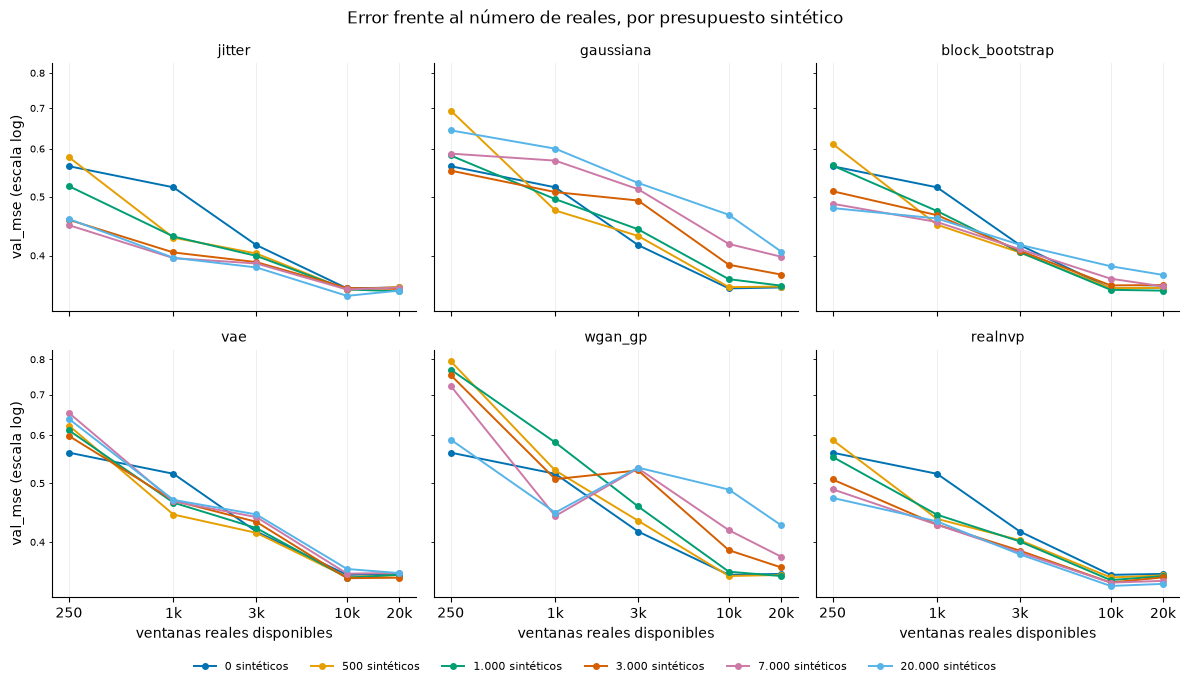

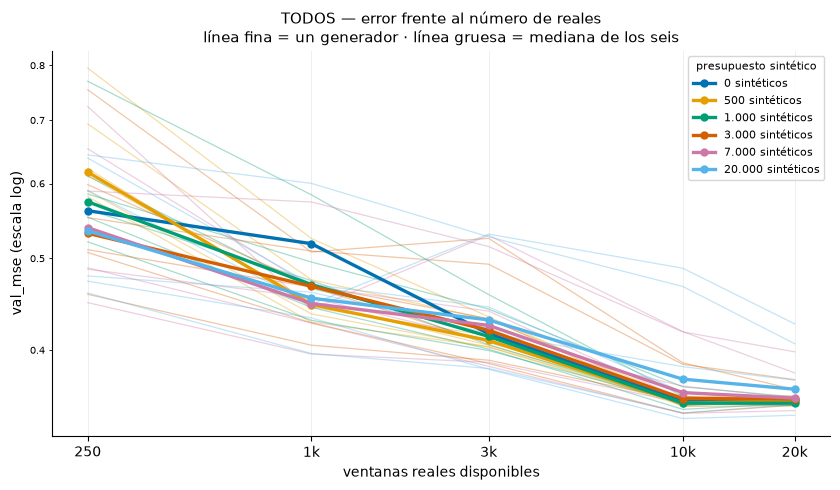

In [12]:
fig27 = plot_curvas_error_por_generador(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                        GENERADORES, metrica="val_mse")
fig27.savefig(cfg.fig_dir / "27_curvas_error_por_generador.png",
              dpi=120, bbox_inches="tight")

fig28 = plot_curvas_error_todos(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                GENERADORES, metrica="val_mse")
fig28.savefig(cfg.fig_dir / "28_curvas_error_todos.png", dpi=120, bbox_inches="tight")


In [13]:
# Las tres tablas que sostienen la lectura de abajo. Se calculan del CSV, no
# se copian a mano: si la malla cambia, el texto se queda obsoleto a la vista.

# (1) Convergencia: cuánto separa a la mejor de la peor celda en cada régimen.
conv = df_curvas.groupby("n_real")["val_mse"].agg(["min", "max"])
conv["cociente"] = conv["max"] / conv["min"]
print("Dispersión entre celdas — cuánto importa elegir bien el generador:")
display(conv.round(3))

# (2) Veredictos pareados por semilla, misma regla que §2.1.b (|t| >= 2,5).
#     En val_mse menos es mejor, de ahí mas_es_mejor=False.
par_curvas = delta_pareado(df_curvas, metrica="val_mse",
                           presupuesto="n_synth", mas_es_mejor=False)
print("\nVeredictos por régimen de escasez:")
display(pd.crosstab(par_curvas.n_real, par_curvas.veredicto))

# (3) ¿Hay óptimo intermedio? Pendiente de val_mse frente a log(n_synth).
#     Positiva = más sintéticos, más error. Si la relación fuese en U, el signo
#     cambiaría dentro de una misma fila; que no lo haga es la refutación de H2.
pend = {}
for g in GENERADORES:
    pend[g] = {n: np.polyfit(np.log(s.index), s.values, 1)[0]
               for n in N_REALES_CURVAS
               for s in [df_curvas[(df_curvas.generador == g) & (df_curvas.n_real == n) &
                                   (df_curvas.n_synth > 0)]
                         .groupby("n_synth")["val_mse"].mean()]}
print("\nPendiente de val_mse vs log(n_synth) — el signo lo fija el generador:")
display(pd.DataFrame(pend).T.loc[GENERADORES].round(3))

# El detalle completo, por si hace falta mirar una celda concreta.
print("\nval_mse medio (filas: generador × presupuesto sintético | columnas: reales):")
display(df_curvas.pivot_table(index=["generador", "n_synth"], columns="n_real",
                              values="val_mse", aggfunc="mean").round(3))


Dispersión entre celdas — cuánto importa elegir bien el generador:


,min,max,cociente
n_real,,,
250,0.405,0.892,2.201
1000,0.374,0.687,1.834
3000,0.352,0.697,1.980
10000,0.323,0.527,1.629
20000,0.325,0.494,1.520



Veredictos por régimen de escasez:


veredicto,empeora,mejora,no concluyente
n_real,,,
250,0,0,30
1000,0,0,30
3000,4,12,14
10000,9,5,16
20000,4,1,25



Pendiente de val_mse vs log(n_synth) — el signo lo fija el generador:


,250,1000,3000,10000,20000
jitter,-0.033,-0.010,-0.006,-0.002,-0.000
gaussiana,-0.009,0.035,0.028,0.030,0.015
block_bootstrap,-0.036,-0.000,0.003,0.008,0.005
vae,0.008,0.005,0.008,0.003,0.001
wgan_gp,-0.049,-0.033,0.028,0.036,0.019
realnvp,-0.032,-0.003,-0.006,-0.003,-0.003



val_mse medio (filas: generador × presupuesto sintético | columnas: reales):


n_real                   250    1000   3000   10000  20000
generador       n_synth                                   
block_bootstrap 500      0.611  0.450  0.405  0.354  0.354
                1000     0.563  0.474  0.405  0.351  0.350
                3000     0.511  0.466  0.407  0.357  0.358
                7000     0.487  0.454  0.410  0.366  0.356
                20000    0.479  0.461  0.417  0.384  0.372
gaussiana       500      0.694  0.475  0.431  0.355  0.356
                1000     0.585  0.496  0.442  0.366  0.357
                3000     0.552  0.509  0.493  0.386  0.372
                7000     0.589  0.574  0.515  0.418  0.398
                20000    0.643  0.600  0.527  0.467  0.406
jitter          500      0.581  0.428  0.403  0.351  0.355
                1000     0.521  0.430  0.400  0.352  0.349
                3000     0.458  0.405  0.390  0.354  0.352
                7000     0.449  0.396  0.388  0.352  0.354
                20000    0.460  0.397  0.382  0.343  0.350
ninguno         0        0.562  0.518  0.416  0.353  0.354
realnvp         500      0.589  0.437  0.403  0.350  0.352
                1000     0.553  0.444  0.401  0.346  0.351
                3000     0.507  0.427  0.387  0.343  0.350
                7000     0.489  0.427  0.384  0.343  0.345
                20000    0.473  0.433  0.382  0.339  0.341
vae             500      0.622  0.444  0.414  0.350  0.353
                1000     0.611  0.465  0.422  0.349  0.353
                3000     0.598  0.468  0.432  0.349  0.349
                7000     0.653  0.467  0.440  0.355  0.356
                20000    0.638  0.469  0.444  0.361  0.356
wgan_gp         500      0.795  0.525  0.434  0.352  0.353
                1000     0.770  0.584  0.458  0.357  0.352
                3000     0.754  0.508  0.525  0.388  0.363
                7000     0.724  0.442  0.529  0.418  0.378
                20000    0.590  0.447  0.531  0.488  0.426

#### Lectura

La malla son **465 celdas** (5 niveles de reales × 5 presupuestos sintéticos × 6 generadores
× 3 semillas, más 15 de referencia), 199 minutos en una RTX 4070 Laptop con la campeona
`gru_l` a 100 épocas. Tres cosas que enseña y que la malla de ratios no puede dar.

**1 · El error converge, y con él deja de importar el generador.** El cociente entre la
celda mejor y la peor de cada columna cae de **2,20× con 250 reales a 1,52× con 20.000**.
Con datos escasos, elegir mal el generador duplica el error; con datos abundantes la
decisión pesa la mitad. Es el embudo de la figura, y el argumento más limpio para no
invertir en generadores sofisticados cuando hay datos.

**2 · Ni con 20.000 sintéticos se rescata la escasez severa.** Con el análisis pareado por
semilla del §2.1.b sobre `val_mse`, el reparto de veredictos por régimen es:

| N_real | mejoras | empeoras | no concluyentes |
|---:|---:|---:|---:|
| 250 | **0** | 0 | 30 |
| 1.000 | **0** | 0 | 30 |
| 3.000 | **12** | 4 | 14 |
| 10.000 | 5 | **9** | 16 |
| 20.000 | 1 | 4 | 25 |

Con 250 y con 1.000 ventanas reales **ninguna** de las 60 combinaciones alcanza veredicto, y
eso incluye inundar el entrenamiento con 20.000 sintéticos —un ratio de **80×** con N=250—.
La causa no es que el efecto sea nulo: es que la dispersión entre semillas del solo-real en
esos regímenes (0,115 y 0,161 de R²) se come cualquier efecto. El suelo mínimo de datos
reales **no se compra con cantidad de sintético**.

La otra cara está en N=10.000: cinco mejoras contra nueve empeoras. La ventana en la que el
sintético sirve con esta campeona es **3.000–10.000 ventanas reales**, y es estrecha.

**3 · No hay óptimo intermedio; hay un signo que fija el generador.** Ajustando la pendiente
de `val_mse` frente a `log(n_synth)` en cada celda —negativa = más sintéticos, menos error—
`jitter` y `realnvp` salen negativos en los cinco regímenes, y `gaussiana` y `vae` positivos
en casi todos. El `wgan_gp` cambia de signo: ayuda en escasez severa (−0,049 con N=250) y
estorba en cuanto hay datos (+0,036 con N=10.000). La relación es **monótona dentro de cada
celda**; lo que cambia es hacia dónde, y lo decide la fidelidad del generador, no la
proporción.

## 3 · Análisis crítico

Dos mallas ejecutadas con la campeona `gru_l` congelada a 100 épocas: la **RATIOS_FINOS**,
333 celdas (3 niveles de escasez × 6 ratios × 6 generadores × 3 semillas) y 50 minutos, y la
de **curvas** del §2.5, 465 celdas y 199 minutos. Las hipótesis se escribieron **antes** de
ver los resultados; se contrastan una a una, incluidas las que salieron mal.

### La escasez es real, pero el modelo es inestable en ella

| ventanas reales | R² en test (solo real) | sd entre semillas |
|---:|---:|---:|
| 250 | 0,151 | **0,115** |
| 1.000 | 0,199 | **0,161** |
| 3.000 | 0,338 | 0,022 |
| 88.619 (nb02) | **0,472** | 0,006 |

Hay recorrido de sobra —de 0,15 a 0,47— para que el sintético tenga dónde aportar. Pero la
columna de la derecha es la que gobierna todo lo demás: **con 250 y 1.000 ventanas, dos
semillas del mismo modelo sin sintéticos difieren más entre sí (0,12–0,16 de R²) que
cualquier efecto que busquemos.** Es una propiedad de la campeona recurrente, no del diseño:
la GRU necesita más datos que la CNN para estabilizarse. Cualquier conclusión en esos dos
regímenes está por debajo del ruido, y el pareado por semilla lo refleja declarando **no
concluyentes** 68 de las 72 celdas.

### Contraste de hipótesis

**H1 · "El sintético solo ayuda en régimen de escasez" → REFUTADA, y con más fuerza que
antes.** Esperábamos el máximo beneficio con 250 ventanas. Ocurre lo contrario: con N=250 y
N=1.000 **no hay un solo veredicto de mejora** en la malla de curvas, y las 14 mejoras de la
malla de ratios se concentran en N=3.000 (13 de 14). **Existe un suelo mínimo de datos
reales por debajo del cual generar datos no sirve de nada**, y con esta campeona está entre
1.000 y 3.000 ventanas. Es el hallazgo central y no estaba en el guion.

**H2 · "Existe un óptimo intermedio de proporción" → REFUTADA, y ahora también por abajo.**
Los ratios fraccionarios se añadieron para mirar el tramo que `[0, 1, 3]` se saltaba entero,
entre "nada de sintético" y "tanto sintético como real". La respuesta es que **no hay giro
ahí**: con N=3.000 el efecto ya es significativo y positivo en **0,25×** (`jitter` +0,020,
t=5,4) y crece de forma monótona hasta 5× (`realnvp` +0,081, t=10,6). Una dosis pequeña de
sintético ya ayuda, y más ayuda más. Combinado con la malla de curvas, que llega a 80×, la
relación es monótona en todo el rango explorado y **el signo lo fija el generador, no la
proporción**.

> Consecuencia práctica: la degradación por exceso que anuncia la teoría no aparece con un
> buen generador dentro de este rango. Si existe, está más allá de 5× — y localizarla es un
> experimento aparte, barato de añadir porque la malla es reanudable.

**H3 · "La gaussiana será difícil de batir" → REFUTADA ROTUNDAMENTE.** Es el peor generador
junto al WGAN-GP: 3 celdas significativamente negativas y ninguna positiva, hasta −0,180 con
N=3.000 y ratio 5×. La predicción se apoyaba en que los retornos son casi elípticos a nivel
de covarianza. Los datos dicen lo contrario: **la fidelidad importa, y mucho**. Un generador
que no reproduce colas no solo no ayuda, **envenena** el entrenamiento — y su daño *crece*
con el ratio, que es la firma de un sesgo, no de ruido.

**H4 · "Las redes pierden justo donde harían falta" → CONFIRMADA para WGAN y VAE, REFUTADA
para el flow.** El VAE no mejora en ninguna celda y empeora en 3; el WGAN-GP tampoco mejora
nunca y se hunde con ratio alto (−0,170 con N=3.000). Pero el **RealNVP es, con el jitter,
el mejor generador del taller**: 5 mejoras concluyentes, ninguna empeora, y el mayor efecto
individual de toda la malla (+0,081). El matiz que sí confirma H4: tampoco el flow levanta
nada por debajo de 3.000 ventanas.

**H5 · "El jitter es difícil de batir" → CONFIRMADA.** 6 mejoras concluyentes, **nunca
empeora**, y es el único generador que consigue un veredicto positivo fuera de N=3.000
(+0,076 con N=250 y ratio 5×). Un generador que no aporta información nueva —son ventanas
reales con ruido— compite de tú a tú con tres arquitecturas generativas y supera a dos.

### El resultado que cierra el círculo: la auditoría predice el efecto

Lo más valioso del taller no es qué generador gana, sino que **se puede saber cuál ganará
sin ejecutar la malla**. Correlación de rangos entre la auditoría del notebook 03 —que no
mira el modelo downstream en ningún momento— y la ganancia pareada de esta malla:

| N_real | corr(X,X) rangos | AUC discrim. | W1 por columna | ratio TSTR | ACF de \|r\| | curtosis | corr(X,X) Pearson |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 250 | **−0,89** | −0,83 | −0,83 | +0,83 | +0,77 | +0,66 | +0,14 |
| 1.000 | **−0,89** | −0,83 | −0,83 | +0,83 | +0,77 | +0,66 | +0,14 |
| 3.000 | −0,83 | −0,77 | −0,77 | **+0,89** | +0,71 | +0,60 | +0,26 |
| todos | **−0,89** | −0,83 | −0,83 | +0,83 | +0,77 | +0,66 | +0,14 |

Cuatro lecturas:

1. **El mejor predictor es la correlación de rangos entre posiciones de la ventana**
   (−0,89), y es el único estable en los tres regímenes. Su versión en **Pearson** vale
   +0,14: inútil y con el signo cambiado, porque la gaussiana reproduce la covarianza por
   construcción y aprueba esa métrica sin merecerlo. `err_corr(X,y)` cae en la misma trampa
   y da la cifra idéntica. **La forma ingenua de medir dependencia habría sido engañosa.**

2. **La utilidad TSTR es el mejor predictor entre los que miden utilidad** (+0,83, y +0,89
   justo en N=3.000, el régimen donde hay señal que predecir). Entrenar el modelo solo con
   sintético —21 entrenamientos en el notebook 03— anticipa el orden que estas 333 celdas
   establecen, con dos inversiones.

   > Orden de la malla con N=1.000: `jitter > realnvp > block_bootstrap > vae > gaussiana > wgan_gp`
   > Orden del TSTR (nb03): `realnvp > jitter > vae > block_bootstrap > wgan_gp > gaussiana`

3. **La distancia de Wasserstein por columna reproduce al discriminative AUC cifra por
   cifra** (−0,83 / −0,83 / −0,77), porque induce el mismo orden. Pero el AUC exige entrenar
   un clasificador y la W1 son 60 ordenaciones: es un predictor gratis.

4. **El mecanismo es realismo distribucional, no regularización.** Curtosis y clustering
   correlacionan con el signo esperado (+0,66 y +0,77). Un generador ayuda en la medida en
   que reproduce la distribución.

> **Cautela obligada:** son correlaciones de rangos sobre **n = 6** generadores. Con esa n,
> un Spearman de −0,89 no es significativo en sentido formal; la señal está en que el mismo
> orden se repite en los tres regímenes y en las dos mallas, no en el valor puntual.

### Señal secundaria: el sintético hace parar antes

La época de la que se conservan los pesos cae al añadir sintéticos, y de forma monótona
(N=3.000: **82 → 70 → 64 → 55 → 48 → 47** al pasar de ratio 0 a 0,25 · 0,5 · 1 · 3 · 5). La
validación **real** castiga cada vez antes al modelo entrenado con la mezcla. El efecto es
más nítido cuanto más real hay, y es coherente con la lectura de H3: los sintéticos empujan
hacia una distribución que no es la del problema, y el early stopping lo detecta.

### Limitaciones que hay que declarar en la presentación

1. **Tres semillas son insuficientes en escasez.** 86 de 108 celdas quedan sin veredicto, y
   en N=250 y N=1.000 es *todo*. Con la campeona recurrente la dispersión del solo-real es
   5–7 veces mayor que con la CNN anterior, así que el problema se ha agravado: subir a 8–10
   semillas en esos dos regímenes es la mejora de mayor relación valor/coste.
2. **La ventana útil se ha estrechado y desplazado** respecto a la ejecución con `cnn_l`
   (era 1.000–3.000, ahora 3.000–10.000). El umbral mínimo de datos reales **depende del
   modelo downstream**, no es una constante del problema. Conviene decirlo así en la defensa.
3. **Los ratios se detienen en 5× y los presupuestos del §2.5 en 20.000.** Basta para
   refutar el óptimo intermedio en el rango explorado, no para localizar el punto de giro
   por arriba si existe.
4. Todo se mide sobre **un solo test** (2024–2026), un solo split y un solo problema
   financiero. No se extrapola a otros horizontes ni a otros targets.

### Conclusión para la defensa

> Los datos sintéticos **sí** mejoran el modelo, pero solo por encima de un umbral mínimo de
> datos reales —que depende del modelo downstream— y solo si el generador reproduce las
> colas. Por debajo de ese umbral no hay nada que ganar: el ruido de optimización es mayor
> que cualquier efecto. Y con generadores que gaussianizan la distribución el sintético
> **destruye** el modelo, con un daño que crece con la proporción. El generador más
> sofisticado del taller (WGAN-GP) es de los más peligrosos, y el más trivial (ruido sobre
> datos reales) nunca hace daño.

## 4 · Persistencia

Los CSV de las dos mallas —la de ratios y la de curvas— son el artefacto que alimenta
la presentación. Se guardan en `data/processed/` junto al resto, y se versionan.

In [14]:
resumen.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", index=False)
delta.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_delta.csv", index=False)
resumir(df_curvas).to_csv(cfg.out_dir / "malla_curvas_resumen.csv", index=False)
print("Guardado:")
for p in sorted(cfg.out_dir.glob("malla_*.csv")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")


Guardado:
  malla_curvas.csv  (59 KB)
  malla_curvas_resumen.csv  (14 KB)
  malla_ratios_finos.csv  (41 KB)
  malla_ratios_finos_delta.csv  (13 KB)
  malla_ratios_finos_resumen.csv  (9 KB)
  malla_reducida.csv  (13 KB)
  malla_reducida_delta.csv  (4 KB)
  malla_reducida_resumen.csv  (3 KB)
